# Readme

what this section is about.


# Imports and Load Data

In [3]:
## load packages 
import jieba
import jieba.posseg as pseg
import jieba.analyse
import pandas as pd
import re
import numpy as np
import os
import ast
import pprint


## sklearn imports
from sklearn.feature_extraction.text import CountVectorizer

## lda
from gensim import corpora
import gensim

## visualizing LDA
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
pyLDAvis.enable_notebook()

## plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

_cjk = ['PingFang SC', 'Heiti SC', 'STHeiti', 'SimHei', 'Noto Sans CJK SC']
_avail = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _cjk if f in _avail), None)
if _font:
    matplotlib.rcParams['font.family'] = _font
matplotlib.rcParams['axes.unicode_minus'] = False

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

/opt/anaconda3/lib/python3.13/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
df = pd.read_csv("../data/01_filtered_cases.csv")
df.head()
df.shape

,case_name,case_type,court,date,case_href,full_text,litigant_type
0,刘慷、吉林省射击射箭运动管理中心人事争议民事再审民事裁定书,民事再审,吉林省高级人民法院,2021-11-05,https://wenshu.court.gov.cn/website/wenshu/181...,吉林省高级人民法院\n民 事 裁 定 书\n（2021）吉民再270号\n再审申请人（一审原...,individual
1,刘小宝、赵效男等买卖合同纠纷民事申请再审审查民事裁定书,民事再审,山东省高级人民法院,2021-07-05,https://wenshu.court.gov.cn/website/wenshu/181...,山东省高级人民法院\n民 事 裁 定 书\n（2021）鲁民申3670号\n再审申请人（一审...,individual
2,马晓三、云南省人民检察院劳动争议再审民事判决书,民事再审,云南省高级人民法院,2020-06-09,https://wenshu.court.gov.cn/website/wenshu/181...,云南省高级人民法院\n民 事 判 决 书\n（2019）云民再30号\n抗诉机关：云南省人民...,individual
3,李素萍与北京市木樨园体育运动技术学校劳动争议再审审查与审判监督民事裁定书,民事审判监督,北京市高级人民法院,2020-06-05,https://wenshu.court.gov.cn/website/wenshu/181...,北京市高级人民法院\n民 事 裁 定 书\n（2020）京民申2236号\n再审申请人（一审...,individual
4,马俊岭等十三人故意伤害二审刑事附带民事判决书,刑事二审,陕西省高级人民法院,2018-07-30,https://wenshu.court.gov.cn/website/wenshu/181...,陕西省高级人民法院\n刑 事 附 带 民 事 判 决 书\n（2018）陕刑终147号\n原...,individual


(79, 7)

# preprocess text


## 1. define stopwords for text cleaning

In [5]:
# Strip out : general Chinese stopwords + 
# legal boilerplate and procedural terms to strip before topic modeling
# Modified: 11 boilerplate terms added after LDA output review (民事判决, 民事裁定,
#   民事, 出生, 汉族, 送达, 公告送达, 案件, 申请, 规定, 京民)
STOPWORDS = set("""
一审 二审 再审 原告 被告 申请人 被申请人 上诉人 被上诉人 驳回上诉 诉至 抗诉 审判长 审判员
书记员 院长 副院长 庭长 法官 助理 合议庭 人民法院 高级人民法院 中级人民法院 基层人民法院
判决 裁定 裁决 判决书 裁定书 法律 如下 认为 依照 根据 查明 本院 经审查 经审理 经查 裁决书 检察院 检察员
中华人民共和国 人民币 甲方 乙方 丙方 甲乙双方 本院认为 无证据 诉讼法 律师费 民法典 公告费 不服 传唤 案外人 给付 
举办方 本院认为 原审 贵院 实缴 该证据 受理费 住所地 辩称 上诉状 判令 载明 诉讼请求 简易程序 采信 起诉 公证费
审批表 诉称 综上 副本 举证 自认 诉请 人民陪审员 开庭 受案 上述事实 本合同 应予 处理结果 不予 提出 证据
答辩 维持原判 驳回 纠纷 驳回 委托 审查 被执行人 撤诉 答辩 终号 因案 维持原判 发回重审 终审 案号 诉讼费用 在案
委托 诉讼 代理人 律师 事务所 法定代表 事务所律师 上诉 立案 依法 组成 进行 审理 本案 现已 终结 请求 依法 一审判决 
第一 判项 改判 诉讼费 事实 理由 承担 
理由 法院 最高人民法院 关于 若干 问题 指导 意见 第三条 第二项 原名 称为 不可 不遗余力 后于
出生 送达 公告送达 案件 申请 规定 京民
""".split())

print(f"Stopword list size: {len(STOPWORDS)}")

Stopword list size: 152


## 2. tokenize

In [6]:
def clean_text(text):
    # keep only chinese characters
    text = re.sub(r'[^一-鿿]', '', text)
    lwords = jieba.lcut(text)
    lwords = [w for w in lwords if w not in STOPWORDS and len(w) > 1]
    # de-dup
    lwords_uniq = list(set(lwords))
    
    return "".join(lwords_uniq)

In [7]:
# # pos checker
# words = pseg.cut("综上" ) #paddle模式
# for word, flag in words:
#     print('%s %s' % (word, flag))

In [8]:
df["keywords"] = df["full_text"].apply(clean_text).apply(
    lambda sentence: jieba.analyse.extract_tags(
        sentence, 
        topK=50,
        withWeight=False, 
        allowPOS=('n', 'nt', 'nz', 'v', 'vn', 'a')
    )
)

df.head()

Building prefix dict from the default dictionary ...
Dumping model to file cache /var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/jieba.cache
Loading model cost 0.530 seconds.
Prefix dict has been built successfully.


,case_name,case_type,court,date,case_href,full_text,litigant_type,keywords
0,刘慷、吉林省射击射箭运动管理中心人事争议民事再审民事裁定书,民事再审,吉林省高级人民法院,2021-11-05,https://wenshu.court.gov.cn/website/wenshu/181...,吉林省高级人民法院\n民 事 裁 定 书\n（2021）吉民再270号\n再审申请人（一审原...,individual,"[吉体, 劳动厅, 航模, 补上去, 人事厅, 劳动局, 机构编制, 慷本, 体工, 中有书..."
1,刘小宝、赵效男等买卖合同纠纷民事申请再审审查民事裁定书,民事再审,山东省高级人民法院,2021-07-05,https://wenshu.court.gov.cn/website/wenshu/181...,山东省高级人民法院\n民 事 裁 定 书\n（2021）鲁民申3670号\n再审申请人（一审...,individual,"[历下区, 海蝶, 男因, 柴家, 书鲁民, 万床, 申号, 工商登记, 市中区, 民事判决..."
2,马晓三、云南省人民检察院劳动争议再审民事判决书,民事再审,云南省高级人民法院,2020-06-09,https://wenshu.court.gov.cn/website/wenshu/181...,云南省高级人民法院\n民 事 判 决 书\n（2019）云民再30号\n抗诉机关：云南省人民...,individual,"[省体, 法制报, 云南省人民政府, 身份, 奖惩条例, 国家经贸委, 申诉人, 待岗, 字..."
3,李素萍与北京市木樨园体育运动技术学校劳动争议再审审查与审判监督民事裁定书,民事审判监督,北京市高级人民法院,2020-06-05,https://wenshu.court.gov.cn/website/wenshu/181...,北京市高级人民法院\n民 事 裁 定 书\n（2020）京民申2236号\n再审申请人（一审...,individual,"[人事科, 周润, 体育训练, 表中, 套改, 木樨园, 京民, 书京民, 申号, 原系, ..."
4,马俊岭等十三人故意伤害二审刑事附带民事判决书,刑事二审,陕西省高级人民法院,2018-07-30,https://wenshu.court.gov.cn/website/wenshu/181...,陕西省高级人民法院\n刑 事 附 带 民 事 判 决 书\n（2018）陕刑终147号\n原...,individual,"[洗杯, 枕部, 监控室, 侧脑室, 碑林区, 挫裂伤, 酒吧女, 鉴定费, 塑料箱, 操作..."


In [9]:
# export df with tokenized keywords for later analysis

df.to_csv("../data/02_tokenized.csv", index=False)
print(f"Saved to {os.path.abspath('../data/')}")

Saved to /Users/wyx/Library/CloudStorage/OneDrive-DartmouthCollege/qss20_athlete_court_complaints/data


# Determine Number of Topics for Gensim LDA Topic Modeling

In [16]:
corpus = df["keywordsl"] = df["keywords"]

dirichlet_dict = corpora.Dictionary(corpus)
bow_corpus = [dirichlet_dict.doc2bow(text) for text in corpus]

# Considering 1-15 topics, as the last is cut off
num_topics = list(range(16)[1:])
num_keywords = 15

LDA_models = {}
LDA_topics = {}
for i in num_topics:
    LDA_models[i] = LdaModel(corpus=bow_corpus,
                             id2word=dirichlet_dict,
                             num_topics=i,
                             update_every=1,
                             chunksize=len(bow_corpus),
                             passes=20,
                             alpha='auto',
                             random_state=42)

    shown_topics = LDA_models[i].show_topics(num_topics=i, 
                                             num_words=num_keywords,
                                             formatted=False)
    LDA_topics[i] = [[word[0] for word in topic[1]] for topic in shown_topics]

/opt/anaconda3/lib/python3.13/site-packages/gensim/models/ldamodel.py:142: RuntimeWarning: invalid value encountered in scalar divide
  b = np.sum(gradf / q) / (1 / c + np.sum(1 / q))


In [27]:
def jaccard_similarity(topic_1, topic_2):
    """
    Derives the Jaccard similarity of two topics

    Jaccard similarity:
    - A statistic used for comparing the similarity and diversity of sample sets
    - J(A,B) = (A ∩ B)/(A ∪ B)
    - Goal is low Jaccard scores for coverage of the diverse elements
    """
    intersection = set(topic_1).intersection(set(topic_2))
    union = set(topic_1).union(set(topic_2))
                    
    return float(len(intersection))/float(len(union))

In [48]:
LDA_stability = {}
for n in num_topics:
    jaccard_sims = []
    topics = LDA_topics[n]
    for i, topic1 in enumerate(topics):
        for j, topic2 in enumerate(topics):
            if i >= j:  # skip self-comparisons and duplicates
                continue
            jaccard_sims.append(jaccard_similarity(topic1, topic2))
    
    LDA_stability[n] = jaccard_sims

mean_stabilities = [np.array(LDA_stability[i]).mean() for i in num_topics]

/var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/ipykernel_2509/3724735818.py:13: RuntimeWarning: Mean of empty slice.
  mean_stabilities = [np.array(LDA_stability[i]).mean() for i in num_topics]
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


15

[np.float64(nan),
 np.float64(0.2),
 np.float64(0.18703703703703703),
 np.float64(0.050985221674876846),
 np.float64(0.0651505199781062),
 np.float64(0.061403526231112435),
 np.float64(0.0594384998325885),
 np.float64(0.0503761724579887),
 np.float64(0.06775823155133501),
 np.float64(0.05815306022202574),
 np.float64(0.06588393615380123),
 np.float64(0.04797322728357212),
 np.float64(0.06321959476728245),
 np.float64(0.04353315487473682),
 np.float64(0.042914824638962575)]

In [41]:
coherences = [CoherenceModel(model=LDA_models[i], texts=corpus, dictionary=dirichlet_dict, coherence='c_v').get_coherence()\
              for i in num_topics]

In [51]:
coh_sta_diffs = [coherences[i] - mean_stabilities[i] for i in range(2, max(num_topics))] # limit topic numbers to the number of keywords
coh_sta_max = max(coh_sta_diffs)
coh_sta_max_idxs = [i for i, j in enumerate(coh_sta_diffs) if j == coh_sta_max]
ideal_topic_num_index = np.argmax(coh_sta_diffs)
ideal_topic_num = num_topics[ideal_topic_num_index]

<Figure size 2000x1000 with 0 Axes>

Text(0, 8, 'nan')

Text(0, 8, '0.200')

Text(0, 8, '0.187')

Text(0, 8, '0.051')

...

Text(0, -14, '0.644')

Text(0, -14, '0.538')

Text(0, -14, '0.696')

Text(0, -14, '0.655')

ValueError: Axis limits cannot be NaN or Inf

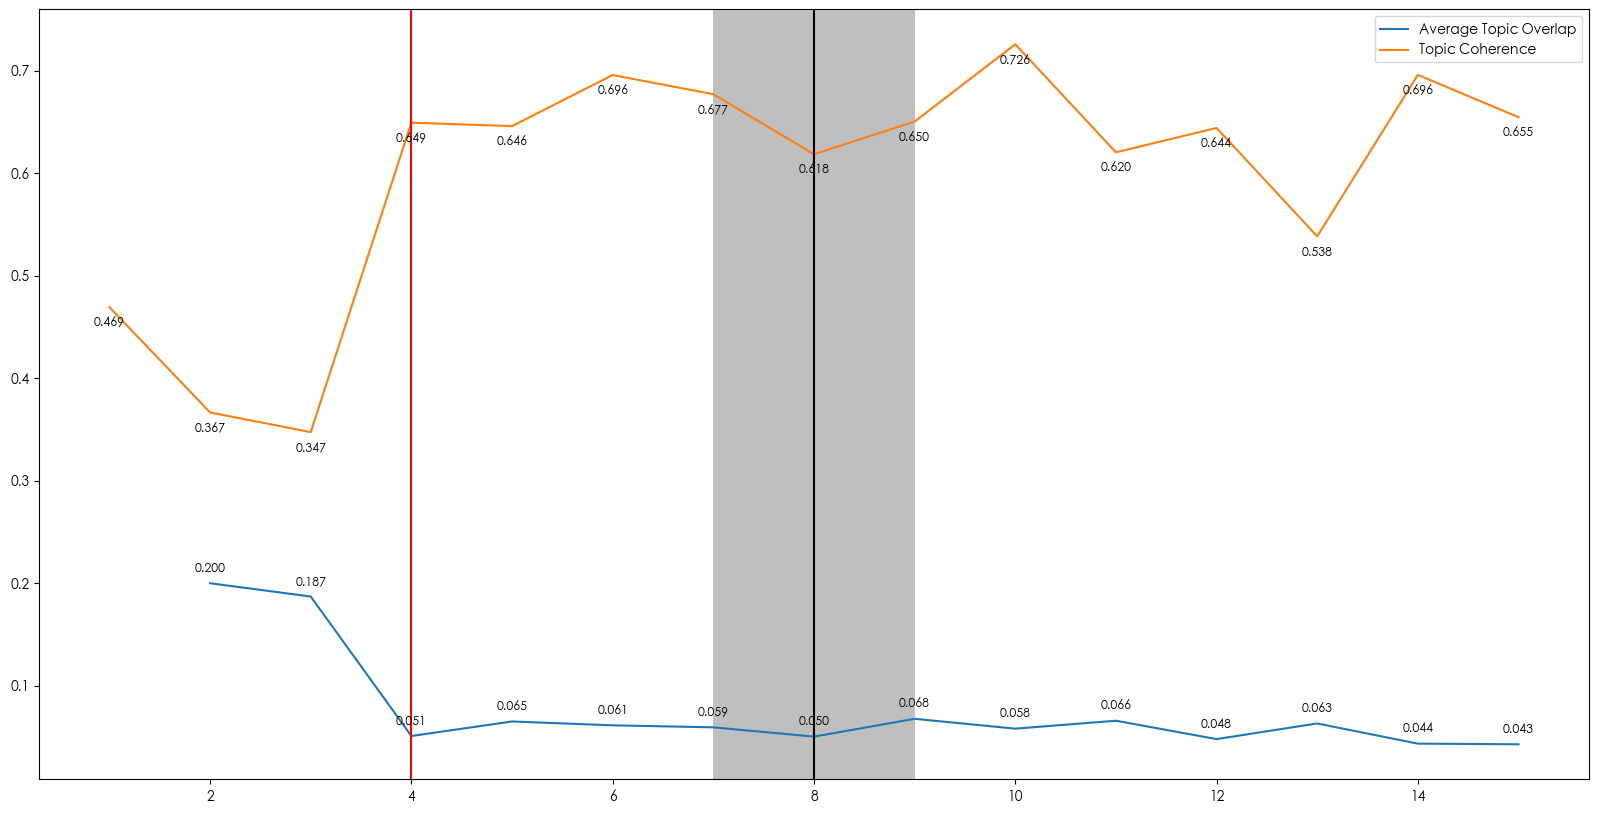

In [59]:
plt.figure(figsize=(20,10))
ax = sns.lineplot(x=num_topics, y=mean_stabilities, label='Average Topic Overlap')
ax = sns.lineplot(x=num_topics, y=coherences, label='Topic Coherence')

for x, y in zip(num_topics, mean_stabilities):
    ax.annotate(f'{y:.3f}', 
                xy=(x, y), 
                xytext=(0, 8),           # offset in points
                textcoords='offset points',
                ha='center', fontsize=9)

for x, y in zip(num_topics, coherences):
    ax.annotate(f'{y:.3f}', 
                xy=(x, y), 
                xytext=(0, -14),        # offset downward to avoid overlap
                textcoords='offset points',
                ha='center', fontsize=9)

ax.axvline(x=ideal_topic_num, label='Ideal Number of Topics', color='black')
ax.axvspan(xmin=ideal_topic_num - 1, xmax=ideal_topic_num + 1, alpha=0.5, facecolor='grey')

y_max = max(max(mean_stabilities), max(coherences)) + (0.10 * max(max(mean_stabilities), max(coherences)))
ax.set_ylim([0, y_max])
ax.set_xlim([1, num_topics[-1]-1])
                
ax.axes.set_title('Model Metrics per Number of Topics', fontsize=25)
ax.set_ylabel('Metric Level', fontsize=20)
ax.set_xlabel('Number of Topics', fontsize=20)
plt.legend(fontsize=20)
plt.show()   

# Unsupervised topic modeling via Gensim

In [14]:
# keywords column already in lists format from cleaning step (corpus)
# RE: corpus = df["keywordsl"] = df["keywords"]

df['keywordsl']

0     [吉体, 劳动厅, 航模, 补上去, 人事厅, 劳动局, 机构编制, 慷本, 体工, 中有书...
1     [历下区, 海蝶, 男因, 柴家, 书鲁民, 万床, 申号, 工商登记, 市中区, 民事判决...
2     [省体, 法制报, 云南省人民政府, 身份, 奖惩条例, 国家经贸委, 申诉人, 待岗, 字...
3     [人事科, 周润, 体育训练, 表中, 套改, 木樨园, 京民, 书京民, 申号, 原系, ...
4     [洗杯, 枕部, 监控室, 侧脑室, 碑林区, 挫裂伤, 酒吧女, 鉴定费, 塑料箱, 操作...
                            ...                        
74    [人事科, 体育院校, 扣出, 赞助费, 帮教, 社失, 背跃, 发号, 原系, 丰行, 午...
75    [入队, 社保费, 国家人事部, 人事厅, 试用期, 营养费, 纪程, 文体局, 发入, 运...
76    [转干, 服从分配, 人事厅, 领导批示, 归责, 统分, 物资局, 体育系, 回系, 报省...
77    [五险, 车车, 象棋队, 健康权, 鉴定费, 对庭, 相碰撞, 损失费, 明细表, 全勤奖...
78    [因私护照, 省级机关, 外事办, 附随, 奥林匹克公园, 体院, 乒乓球队, 体育训练, ...
Name: keywordsl, Length: 79, dtype: object

In [15]:
## Step 1: re-tokenize and store in list
## here, i'm doing with the raw random sample of text
## in activity, you should do with the preprocessed texts
text_raw_tokens = [one_text for one_text in df.keywordsl]

## Step 2: use gensim create dictionary - gets all unique words across documents
text_raw_dict = corpora.Dictionary(text_raw_tokens)
raw_len = len(text_raw_dict) # get length for comparison below

### explore first few keys and values
### see that key is just an arbitrary counter; value is the word itself
{k: text_raw_dict[k] for k in list(text_raw_dict)[:5]}


## Step 3: filter out very rare and very common words
## here, i'm using the threshold that a word needs to appear in at least
## 5% of docs but not more than 95%
## this is an integer count of docs so i round
lower_bound = round(df.shape[0]*0.05)
upper_bound = round(df.shape[0]*0.95)

### apply filtering to dictionary
text_raw_dict.filter_extremes(no_below = lower_bound,
                             no_above = upper_bound)
print(f'Filtering out very rare and very common words reduced the \
length of dictionary from {str(raw_len)} to {str(len(text_raw_dict))}.')
{k: text_raw_dict[k] for k in list(text_raw_dict)[:5]} # show first five entries after filtering


## Step 4: apply dictionary to TOKENIZED texts
## this creates a mapping between each word 
## in a specific listing and the key in the dictionary.
## for words that remain in the filtered dictionary,
## output is a list where len(list) == n documents
## and each element in the list is a list of tuples
## containing the mappings
corpus_fromdict = [text_raw_dict.doc2bow(one_text) 
                   for one_text in text_raw_tokens]

### can apply doc2bow(one_text, return_missing = True) to print words
### eliminated from the listing bc they're not in filtered dictionary.
### but feeding that one with missing values to
### the lda function can cause errors
corpus_fromdict_showmiss = [text_raw_dict.doc2bow(one_text, return_missing = True)
                            for one_text in text_raw_tokens]
print('Sample of documents represented in dictionary format (with omitted words noted):')
corpus_fromdict_showmiss[:10]

{0: '中有书吉民', 1: '人事厅', 2: '人事处', 3: '人员名单', 4: '人王'}

Filtering out very rare and very common words reduced the length of dictionary from 2009 to 216.


{0: '人事厅', 1: '人事处', 2: '体委', 3: '体工', 4: '体工队'}

Sample of documents represented in dictionary format (with omitted words noted):


[([(0, 1),
   (1, 1),
   (2, 1),
   (3, 1),
   (4, 1),
   (5, 1),
   (6, 1),
   (7, 1),
   (8, 1),
   (9, 1),
   (10, 1),
   (11, 1),
   (12, 1),
   (13, 1),
   (14, 1),
   (15, 1)],
  {'中有书吉民': 1,
   '人员名单': 1,
   '人王': 1,
   '体育事业': 1,
   '偏袒': 1,
   '劳动厅': 1,
   '原省': 1,
   '合法利益': 1,
   '吉体': 1,
   '名册': 1,
   '团体冠军': 1,
   '委以': 1,
   '工作失误': 1,
   '工资表': 1,
   '开庭审理': 1,
   '慷本': 1,
   '手写': 1,
   '扩大会': 1,
   '提审': 1,
   '文龙': 1,
   '机构编制': 1,
   '现住': 1,
   '离校': 1,
   '红头文件': 1,
   '绿园区': 1,
   '航模': 1,
   '补上去': 1,
   '补报': 1,
   '证据不足': 1,
   '调令': 1,
   '转业': 1,
   '转递': 1,
   '销应': 1,
   '龙运': 1}),
 ([(5, 1), (12, 1), (13, 1), (16, 1), (17, 1), (18, 1), (19, 1)],
  {'万床': 1,
   '书鲁民': 1,
   '供货': 1,
   '公司法': 1,
   '公示': 1,
   '出资': 1,
   '办事处': 1,
   '占用': 1,
   '历下区': 1,
   '受害者': 1,
   '可知': 1,
   '商贸': 1,
   '增资': 1,
   '实质性': 1,
   '工商登记': 1,
   '市中区': 1,
   '带病': 1,
   '当事人': 1,
   '录音': 1,
   '挫折': 1,
   '推翻': 1,
   '提交': 1,
   '文化课': 1,
   '无关': 1,
   '柴家': 1,
   '

In [53]:
## Step 5: we're finally ready to estimate the model!
## full documentation here - https://radimrehurek.com/gensim/models/ldamodel.html
## here, we're feeding the lda function:
ldamod = gensim.models.ldamodel.LdaModel(corpus_fromdict,
                                         num_topics = 8, 
                                         id2word=text_raw_dict, 
                                         passes=15, 
                                         alpha ='auto',
                                         per_word_topics = True,
                                        random_state=42)

print(type(ldamod))

<class 'gensim.models.ldamodel.LdaModel'>


## Seeing what topics the estimated model discovers

In [54]:
## Post-model 1: explore corpus-wide summary of topics
### getting the topics and top words; can retrieve diff top words
topics = ldamod.print_topics(num_words = 15)
for topic in topics:
    print(topic)

(0, '0.057*"微信" + 0.051*"截图" + 0.038*"抚慰金" + 0.032*"财产损失" + 0.032*"赔偿损失" + 0.026*"文末" + 0.026*"二维码" + 0.026*"侵权行为" + 0.026*"致歉" + 0.026*"肖像权" + 0.026*"版面" + 0.026*"百科" + 0.026*"责任法" + 0.026*"入职" + 0.024*"培训费"')
(1, '0.042*"中因" + 0.037*"体育运动" + 0.027*"木樨园" + 0.025*"工龄" + 0.025*"受理" + 0.025*"退役" + 0.025*"运动员" + 0.025*"民事" + 0.025*"体育训练" + 0.025*"纠纷案件" + 0.025*"代表人" + 0.025*"社会保险" + 0.018*"庭审" + 0.018*"技术学校" + 0.017*"内向"')
(2, '0.035*"补偿费" + 0.034*"聘用" + 0.033*"择业" + 0.032*"体育局" + 0.027*"停发" + 0.025*"赔偿金" + 0.025*"工伤保险" + 0.025*"国家体育总局" + 0.025*"伤病" + 0.022*"辞退" + 0.021*"共融" + 0.019*"书面通知" + 0.019*"补助金" + 0.018*"运龄" + 0.018*"存档"')
(3, '0.024*"履行合同" + 0.022*"借条" + 0.022*"转款" + 0.022*"出借" + 0.022*"公司财务" + 0.022*"下属单位" + 0.022*"补救措施" + 0.021*"授权书" + 0.021*"欠付" + 0.019*"公章" + 0.019*"经手人" + 0.019*"强强" + 0.019*"补充协议" + 0.019*"兽药" + 0.019*"计付"')
(4, '0.029*"体育局" + 0.026*"民事判决" + 0.025*"择业" + 0.024*"人事处" + 0.023*"人事厅" + 0.021*"运动队" + 0.021*"体委" + 0.020*"工资待遇" + 0.018*"离队" + 0.018*"退役费" + 0.017*"补

### Visualization 

In [55]:
lda_display = gensimvis.prepare(ldamod, corpus_fromdict, text_raw_dict)
pyLDAvis.display(lda_display)

In [56]:
# as HTML file
pyLDAvis.save_html(lda_display, '../output/lda_vis_chn_8.html')